# Generative modelling


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
# Define the path to your data and result folders in Google Drive
# data_path="data"
data_path = '/content/drive/MyDrive/data/generative_modelling'

In [ ]:
# install dependencies
!pip install -q numpy pandas matplotlib tensorflow scikit-learn scipy

In this notebook we look at how a generative modelling approach can be used for chemometrics. We train conditional GANs (pix2pix-style, following Mishra 2022, "Deep generative neural networks for spectral image processing") to turn a PLS-compressed hyperspectral image directly into a segmentation mask, and separately into a per-pixel soluble solids content (SSC) map.

The `.mat` file contains a single grape data set (segmentation + SSC regression), so we build the segmentation and regression cGANs from the paper, but not the classification one (there's no matching data for it here).

Alongside the code we plot the raw scene, a few training patches, the training curves, and the predictions themselves, so it's easier to see what each stage is actually doing rather than just reading numbers.

## Imports, setup, and a GPU check

In [1]:
import os
import gc
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.initializers import RandomNormal
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv2D, Conv2DTranspose, LeakyReLU, Activation,
    Concatenate, Dropout, BatchNormalization,
)

import warnings
warnings.filterwarnings('ignore')

# np.random.seed(42)
# tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs visible to TensorFlow: {gpus if gpus else 'none'}")

if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("No GPU detected by TensorFlow - training below will run on CPU and be much slower.")


2026-09-07 16:41:25.773061: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-07 16:41:26.535803: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-07 16:41:28.521808: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.20.0
GPUs visible to TensorFlow: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Reading data


In [ ]:
filename = f'{data_path}/for_GAN.mat'
mat_data = loadmat(filename)

mat_data.keys()

dict_keys(['__header__', '__version__', '__globals__', 'SSC_test_im', 'SSC_train_im', 'SSC_training', 'Wavelength', 'im_test_pls_pre', 'im_test_pls_raw', 'im_train_pls_pre', 'im_train_pls_raw', 'image_test_pre', 'image_train_pre', 'img_test', 'img_train', 'mask_test', 'mask_training', 'means', 'stds', 'im_test_pls_pre_normalised', 'im_train_pls_pre_normalised'])

In [3]:
# Inspect what we actually have to work with
for key in ['img_train', 'img_test', 'im_train_pls_pre', 'im_test_pls_pre',
            'mask_training', 'mask_test', 'SSC_train_im', 'SSC_test_im']:
    if key in mat_data:
        arr = mat_data[key]
        print(f"{key:22s} shape={str(arr.shape):20s} dtype={arr.dtype}")

img_train              shape=(399, 501, 140)      dtype=float64
img_test               shape=(399, 501, 140)      dtype=float64
im_train_pls_pre       shape=(399, 501, 13)       dtype=float64
im_test_pls_pre        shape=(399, 501, 13)       dtype=float64
mask_training          shape=(399, 501)           dtype=uint8
mask_test              shape=(399, 501)           dtype=uint8
SSC_train_im           shape=(399, 501)           dtype=float64
SSC_test_im            shape=(399, 501)           dtype=float64


**What we have, mapped onto the paper's terminology:**

| paper concept | variable here |
|---|---|
| PLS-compressed reflectance (input `x`) | `im_train_pls_pre` / `im_test_pls_pre` |
| segmentation ground truth map (`y`) | `mask_training` / `mask_test` |
| regression ground truth map (`y`), SSC broadcast per-pixel within each grape | `SSC_train_im` / `SSC_test_im` |

The paper found PLS-compressed reflectance to be the best- or joint-best-performing input for both segmentation and regression so we use `im_*_pls_pre` throughout rather than the raw reflectance.


A few caveats worth mentioning:

- **One training scene, one test scene.** `im_train_pls_pre` and `im_test_pls_pre` are each a single large hyperspectral image. The 500 patches you cut out of the training image are *not* 500 independent observations - they're overlapping crops of the same physical scene (the same lighting, the same camera, mostly the same ~50 grapes). This is precisely the approach of the paper ("image subsampling for deep learning"), but it means patch count is a measure of how much the network gets to look at the scene, not sample diversity.
- **Segmentation** benefits the most from this kind of patch augmentation, because the network mostly needs to learn a local, translation-invariant "is this pixel grape or background" rule many overlapping crops genuinely help it see that pattern from many angles/positions. This is consistent with the paper reaching Jaccard scores of 0.97–0.99 essentially from a single training image.
- **Regression is the more fragile of the two.** However many patches you extract, the *label diversity* is still only the ~50 SSC values in `SSC_*` images. If most of the patches happen to come from the same few grapes, the model can overfit to that subset.

### Preview the raw scene

Before cutting anything into patches, it's worth looking at the full training scene: one channel of the PLS-compressed image, the segmentation mask, and the SSC map, side by side. 

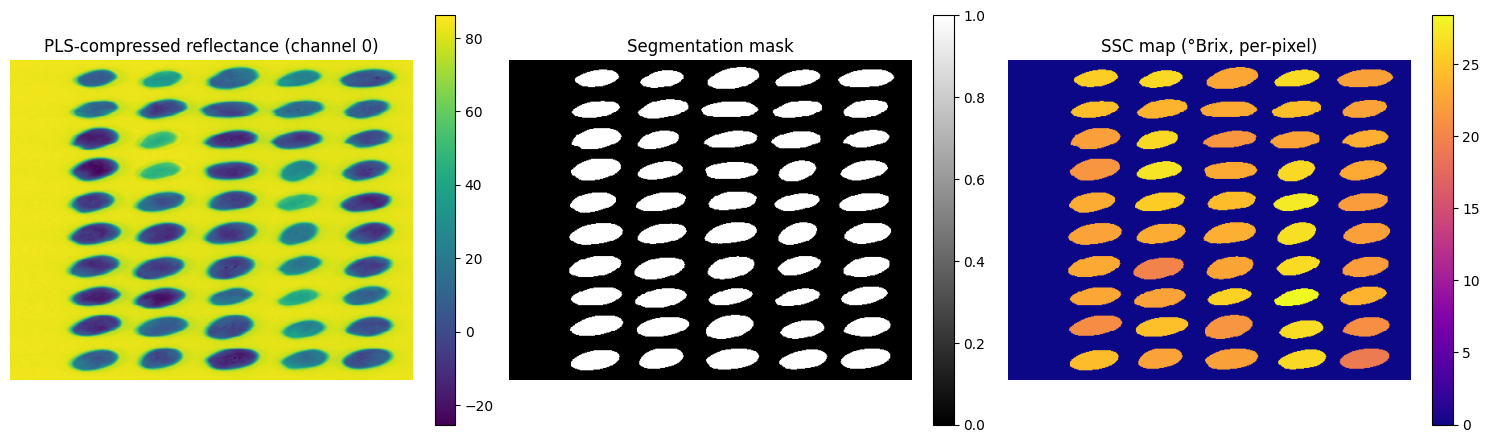

In [4]:
X_train_full = mat_data['im_train_pls_pre']
mask_train_full = mat_data['mask_training']
ssc_train_full = mat_data['SSC_train_im']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

im0 = axes[0].imshow(X_train_full[:, :, 0], cmap='viridis')
axes[0].set_title('PLS-compressed reflectance (channel 0)')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(mask_train_full, cmap='gray')
axes[1].set_title('Segmentation mask')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(ssc_train_full, cmap='plasma')
axes[2].set_title('SSC map (°Brix, per-pixel)')
plt.colorbar(im2, ax=axes[2], fraction=0.046)

for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

### Patch extraction

We cut `num_patches` random `patch_size` x `patch_size` crops out of the training scene, plus the matching crops of the mask and SSC map, so the cGANs get many training examples out of one scene.

**Memory note:** the array loaded from the `.mat` file is `float64` by default. For 500 patches of 256x256 pixels with several PLS channels, that adds up fast — e.g. 500 x 256 x 256 x 13 channels x 8 bytes is already ~3.4 GB, and that's before the mask/SSC copies, and whatever the GPU driver reserves on top. We cast to `float32` immediately after extraction to roughly halve this.


In [5]:
def get_paired_patches(X, Y_dict, patch_size=256, num_patches=500, seed=None):
    """Extract `num_patches` random patch_size x patch_size crops from X, plus matching crops from
    every array in Y_dict (dict of name -> 2D/3D array, same height/width as X).
    Returns (X_patches, {name: Y_patches}), both as float32.
    """
    rng = np.random.default_rng(seed)
    h, w = X.shape[0], X.shape[1]
    X_patches = []
    Y_patches = {name: [] for name in Y_dict}

    for _ in range(num_patches):
        i = rng.integers(0, h - patch_size + 1)
        j = rng.integers(0, w - patch_size + 1)

        X_patches.append(X[i:i + patch_size, j:j + patch_size, :].astype('float32'))

        for name, Y in Y_dict.items():
            patch = Y[i:i + patch_size, j:j + patch_size]
            if patch.ndim == 2:
                patch = np.expand_dims(patch, axis=-1)
            Y_patches[name].append(patch.astype('float32'))

    X_patches = np.array(X_patches, dtype='float32')
    Y_patches = {name: np.array(arr, dtype='float32') for name, arr in Y_patches.items()}
    return X_patches, Y_patches


targets_full = {
    'mask': mask_train_full,
    'ssc': ssc_train_full,
}

X_patches, Y_patches = get_paired_patches(X_train_full, targets_full,
                                           patch_size=256, num_patches=500, seed=0)
mask_patches = Y_patches['mask']
ssc_patches = Y_patches['ssc']

print('X_patches:', X_patches.shape, X_patches.dtype)
print('mask_patches:', mask_patches.shape)
print('ssc_patches:', ssc_patches.shape)
print(f"X_patches memory: {X_patches.nbytes / 1e9:.2f} GB")

X_patches: (500, 256, 256, 13) float32
mask_patches: (500, 256, 256, 1)
ssc_patches: (500, 256, 256, 1)
X_patches memory: 1.70 GB


### A look at a few patches

Since the patches are random crops, it's worth eyeballing a handful before training. This catches obviously broken crops (e.g. all-background patches, or a mask/SSC pair that's shifted relative to the input) much faster than waiting for a training curve to look wrong.

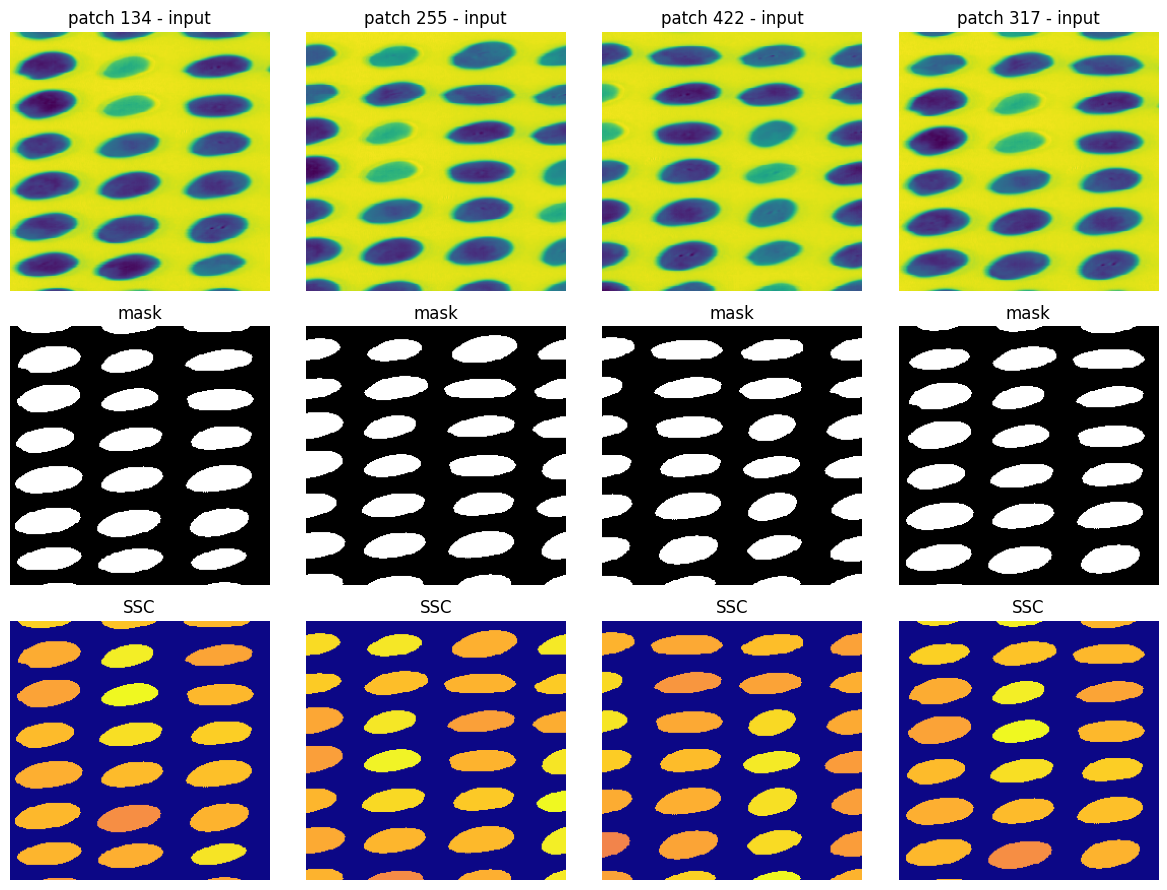

In [6]:
n_preview = 4
rng = np.random.default_rng(0)
preview_idx = rng.choice(X_patches.shape[0], size=n_preview, replace=False)

fig, axes = plt.subplots(3, n_preview, figsize=(3 * n_preview, 9))
for col, idx in enumerate(preview_idx):
    axes[0, col].imshow(X_patches[idx][:, :, 0], cmap='viridis')
    axes[0, col].set_title(f'patch {idx} - input')
    axes[1, col].imshow(mask_patches[idx][:, :, 0], cmap='gray')
    axes[1, col].set_title('mask')
    axes[2, col].imshow(ssc_patches[idx][:, :, 0], cmap='plasma')
    axes[2, col].set_title('SSC')
    for row in range(3):
        axes[row, col].axis('off')
plt.tight_layout()
plt.show()

### Scaling

Following the architecture decsions of pix2pix the generator ends in a sigmoid, so both targets need to be scaled to `[0, 1]`. The input is scaled to `[-1, 1]`, which is the standard pix2pix convention for the encoder input. 


In [7]:
# Input (shared by both tasks)
x_min, x_max = X_patches.min(), X_patches.max()
X_scaled = (X_patches - x_min) / (x_max - x_min)
X_scaled = ((X_scaled - 0.5) * 2.0).astype('float32')  # -> [-1, 1]

# Segmentation target
mask_scaled = mask_patches.astype('uint8')
print(mask_scaled.min(), mask_scaled.max())

# Regression target
ssc_min, ssc_max = ssc_patches.min(), ssc_patches.max()
ssc_scaled = ((ssc_patches - ssc_min) / (ssc_max - ssc_min)).astype('float32')  # -> [0, 1]

print('X_scaled range:', X_scaled.min(), X_scaled.max())
print('mask_scaled range:', mask_scaled.min(), mask_scaled.max())
print('ssc_scaled range:', ssc_scaled.min(), ssc_scaled.max(), '| original SSC range:', ssc_min, ssc_max)

# X_patches is now fully superseded by X_scaled - so we free it before building any models.
del X_patches
gc.collect()


0 1
X_scaled range: -1.0 1.0
mask_scaled range: 0 1
ssc_scaled range: 0.0 1.0 | original SSC range: 0.0 28.4


62

## Build cGAN architecture

Both tasks use the same pix2pix-style architecture:

- **Generator**: a U-Net - a 7-layer convolutional encoder that downsamples the input to a bottleneck, then a mirrored decoder that upsamples back to full resolution. Skip connections join each encoder layer to its corresponding decoder layer, so fine spatial detail lost during downsampling can be recovered directly rather than reconstructed from the bottleneck alone.
- **Discriminator**: a "PatchGAN" - instead of outputting one real/fake score for the whole image, it outputs a grid of scores, one per local patch of the image. This pushes the generator to get local texture and structure right everywhere, not just to fool a single global judgement.
- **Combined GAN model**: wires the generator's output into the discriminator, so the generator's weights get updated to both fool the discriminator and match the target image directly (via the L1/MAE term below).


In [8]:
def define_discriminator(image_shape, mask_shape):
    init = RandomNormal(stddev=0.02)
    in_src_image = Input(shape=image_shape)
    in_target_image = Input(shape=mask_shape)
    merged = Concatenate()([in_src_image, in_target_image])
    d = Conv2D(64, (4, 4), strides=(2, 2), padding='same', kernel_initializer=init)(merged)
    d = LeakyReLU(alpha=0.2)(d)
    d = Conv2D(128, (4, 4), strides=(2, 2), padding='same', kernel_initializer=init)(d)
    d = BatchNormalization()(d)
    d = LeakyReLU(alpha=0.2)(d)
    d = Conv2D(256, (4, 4), strides=(2, 2), padding='same', kernel_initializer=init)(d)
    d = BatchNormalization()(d)
    d = LeakyReLU(alpha=0.2)(d)
    d = Conv2D(512, (4, 4), strides=(2, 2), padding='same', kernel_initializer=init)(d)
    d = BatchNormalization()(d)
    d = LeakyReLU(alpha=0.2)(d)
    d = Conv2D(512, (4, 4), padding='same', kernel_initializer=init)(d)
    d = BatchNormalization()(d)
    d = LeakyReLU(alpha=0.2)(d)
    d = Conv2D(1, (4, 4), padding='same', kernel_initializer=init)(d)
    patch_out = Activation('sigmoid')(d)
    model = Model([in_src_image, in_target_image], patch_out)
    opt = Adam(learning_rate=0.0002, beta_1=0.5)
    model.compile(loss='binary_crossentropy', optimizer=opt, loss_weights=[0.5])
    return model

### Generator (U-Net) and the combined GAN


In [9]:
def define_encoder_block(layer_in, n_filters, batchnorm=True):
    init = RandomNormal(stddev=0.02)
    g = Conv2D(n_filters, (4, 4), strides=(2, 2), padding='same', kernel_initializer=init)(layer_in)
    if batchnorm:
        g = BatchNormalization()(g, training=True)
    g = LeakyReLU(alpha=0.2)(g)
    return g


def decoder_block(layer_in, skip_in, n_filters, dropout=True):
    init = RandomNormal(stddev=0.02)
    g = Conv2DTranspose(n_filters, (4, 4), strides=(2, 2), padding='same', kernel_initializer=init)(layer_in)
    g = BatchNormalization()(g, training=True)
    if dropout:
        g = Dropout(0.5)(g, training=True)
    g = Concatenate()([g, skip_in])
    g = Activation('relu')(g)
    return g


def define_generator(image_shape, out_channels=1):
    init = RandomNormal(stddev=0.02)
    in_image = Input(shape=image_shape)
    e1 = define_encoder_block(in_image, 64, batchnorm=False)
    e2 = define_encoder_block(e1, 128)
    e3 = define_encoder_block(e2, 256)
    e4 = define_encoder_block(e3, 512)
    e5 = define_encoder_block(e4, 512)
    e6 = define_encoder_block(e5, 512)
    e7 = define_encoder_block(e6, 512)
    b = Conv2D(512, (4, 4), strides=(2, 2), padding='same', kernel_initializer=init)(e7)
    b = Activation('relu')(b)
    d1 = decoder_block(b, e7, 512)
    d2 = decoder_block(d1, e6, 512)
    d3 = decoder_block(d2, e5, 512)
    d4 = decoder_block(d3, e4, 512, dropout=False)
    d5 = decoder_block(d4, e3, 256, dropout=False)
    d6 = decoder_block(d5, e2, 128, dropout=False)
    d7 = decoder_block(d6, e1, 64, dropout=False)
    g = Conv2DTranspose(out_channels, (4, 4), strides=(2, 2), padding='same', kernel_initializer=init)(d7)
    out_image = Activation('sigmoid')(g)
    model = Model(in_image, out_image)
    return model


def define_gan(g_model, d_model, image_shape):
    for layer in d_model.layers:
        if not isinstance(layer, BatchNormalization):
            layer.trainable = False
    in_src = Input(shape=image_shape)
    gen_out = g_model(in_src)
    dis_out = d_model([in_src, gen_out])
    model = Model(in_src, [dis_out, gen_out])
    opt = Adam(learning_rate=0.0002, beta_1=0.5)
    model.compile(loss=['binary_crossentropy', 'mae'], optimizer=opt, loss_weights=[1, 100])
    return model

## Train the cGAN model

The training loop below follows the standard pix2pix recipe: for each step, sample a batch of real pairs and a batch of generator-produced (fake) pairs, update the discriminator on both, then update the generator through the combined GAN model. `n_batch=4` is deliberately small - with 256x256 images and a 7-layer U-Net, even a modest batch size uses a fair amount of memory per step. 

In [10]:
def generate_real_samples(dataset, n_samples, patch_shape):
    trainA, trainB = dataset
    ix = np.random.randint(0, trainA.shape[0], n_samples)
    X1, X2 = trainA[ix], trainB[ix]
    y = np.ones((n_samples, patch_shape, patch_shape, 1))
    return [X1, X2], y


def generate_fake_samples(g_model, samples, patch_shape):
    X = g_model.predict(samples, verbose=0)
    y = np.zeros((len(X), patch_shape, patch_shape, 1))
    return X, y


def summarize_performance(step, g_model, dataset, n_samples=3, out_dir='.'):
    [X_realA, X_realB], _ = generate_real_samples(dataset, n_samples, 1)
    X_fakeB, _ = generate_fake_samples(g_model, X_realA, 1)
    # X_realA was scaled to [-1, 1]; X_realB / X_fakeB are already in [0, 1] (sigmoid output)
    X_realA_vis = (X_realA + 1) / 2.0

    for i in range(n_samples):
        plt.subplot(3, n_samples, 1 + i)
        plt.axis('off')
        plt.imshow(X_realA_vis[i][:, :, 0], cmap='gray')
    for i in range(n_samples):
        plt.subplot(3, n_samples, 1 + n_samples + i)
        plt.axis('off')
        plt.imshow(X_fakeB[i][:, :, 0])
    for i in range(n_samples):
        plt.subplot(3, n_samples, 1 + n_samples * 2 + i)
        plt.axis('off')
        plt.imshow(X_realB[i][:, :, 0])
    filename1 = f'{out_dir}/plot_%06d.png' % (step + 1)
    plt.savefig(filename1)
    plt.close()
    filename2 = f'{out_dir}/model_%06d.h5' % (step + 1)
    g_model.save(filename2)
    print('>Saved: %s and %s' % (filename1, filename2))


def train(d_model, g_model, gan_model, dataset, n_epochs=50, n_batch=4, out_dir='.', summarize_every=None):
    """Standard pix2pix training loop. Returns a history dict of per-batch losses."""
    os.makedirs(out_dir, exist_ok=True)
    n_patch = d_model.output_shape[1]
    trainA, trainB = dataset
    bat_per_epo = int(len(trainA) / n_batch)
    n_steps = bat_per_epo * n_epochs
    if summarize_every is None:
        summarize_every = bat_per_epo * 10  # roughly every 10 epochs

    history = {'d_loss1': [], 'd_loss2': [], 'g_loss': []}

    for i in range(n_steps):
        [X_realA, X_realB], y_real = generate_real_samples(dataset, n_batch, n_patch)
        X_fakeB, y_fake = generate_fake_samples(g_model, X_realA, n_patch)

        d_loss1 = d_model.train_on_batch([X_realA, X_realB], y_real)
        d_loss2 = d_model.train_on_batch([X_realA, X_fakeB], y_fake)

        g_loss, _, _ = gan_model.train_on_batch(X_realA, [y_real, X_realB])

        history['d_loss1'].append(d_loss1)
        history['d_loss2'].append(d_loss2)
        history['g_loss'].append(g_loss)

        if (i + 1) % 50 == 0 or i == n_steps - 1:
            print('>%d/%d, d1[%.3f] d2[%.3f] g[%.3f]' % (i + 1, n_steps, d_loss1, d_loss2, g_loss))
        if (i + 1) % summarize_every == 0:
            summarize_performance(i, g_model, dataset, out_dir=out_dir)

    return history


def plot_history(history, title=''):
    plt.figure(figsize=(8, 4))
    plt.plot(history['d_loss1'], label='discriminator (real)', alpha=0.7)
    plt.plot(history['d_loss2'], label='discriminator (fake)', alpha=0.7)
    plt.plot(history['g_loss'], label='generator', alpha=0.7)
    plt.xlabel('batch')
    plt.ylabel('loss')
    plt.title(title)
    plt.legend()
    plt.show()

## Train and evaluate segmentation


I0000 00:00:1788792112.087820   26835 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13449 MB memory:  -> device: 0, name: NVIDIA RTX A5500 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6
2026-09-07 16:41:53.518688: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f72a4001e90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-09-07 16:41:53.518736: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA RTX A5500 Laptop GPU, Compute Capability 8.6
2026-09-07 16:41:53.559511: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-09-07 16:41:54.010544: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 92501
2026-09-07 16:41:55.928134: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm e

>50/1250, d1[0.459] d2[0.461] g[25.487]
>100/1250, d1[0.455] d2[0.456] g[17.247]
>150/1250, d1[0.453] d2[0.453] g[13.207]
>200/1250, d1[0.451] d2[0.452] g[10.799]
>250/1250, d1[0.450] d2[0.451] g[9.192]
>300/1250, d1[0.450] d2[0.450] g[8.039]
>350/1250, d1[0.449] d2[0.450] g[7.158]
>400/1250, d1[0.449] d2[0.449] g[6.469]
>450/1250, d1[0.449] d2[0.449] g[5.908]
>500/1250, d1[0.449] d2[0.449] g[5.451]
>550/1250, d1[0.449] d2[0.449] g[5.060]
>600/1250, d1[0.449] d2[0.449] g[4.728]
>650/1250, d1[0.448] d2[0.449] g[4.440]
>700/1250, d1[0.448] d2[0.449] g[4.189]
>750/1250, d1[0.448] d2[0.449] g[3.967]
>800/1250, d1[0.448] d2[0.449] g[3.769]
>850/1250, d1[0.448] d2[0.449] g[3.592]
>900/1250, d1[0.448] d2[0.449] g[3.432]
>950/1250, d1[0.448] d2[0.449] g[3.288]
>1000/1250, d1[0.448] d2[0.449] g[3.155]
>1050/1250, d1[0.449] d2[0.449] g[3.034]
>1100/1250, d1[0.449] d2[0.449] g[2.924]
>1150/1250, d1[0.449] d2[0.449] g[2.822]
>1200/1250, d1[0.449] d2[0.449] g[2.727]
>1250/1250, d1[0.449] d2[0.449] 

>Saved: data/generative_modelling/segmentation_run/plot_001250.png and data/generative_modelling/segmentation_run/model_001250.h5


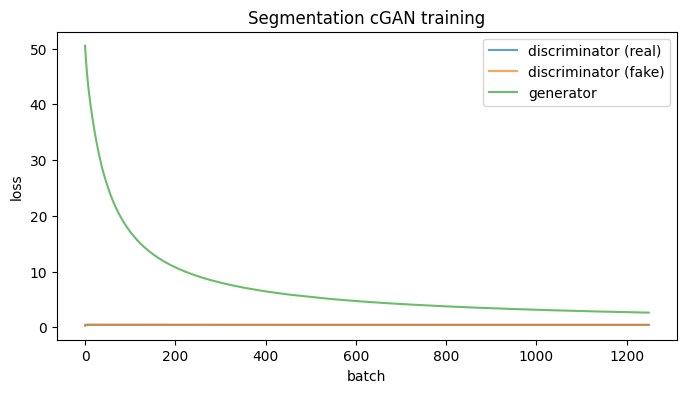

In [11]:
image_shape = X_scaled.shape[1:]     # (256, 256, n_pls_components)
mask_shape = mask_scaled.shape[1:]   # (256, 256, 1)

d_model_seg = define_discriminator(image_shape, mask_shape)
g_model_seg = define_generator(image_shape, out_channels=1)
gan_model_seg = define_gan(g_model_seg, d_model_seg, image_shape)

dataset_seg = [X_scaled, mask_scaled]

# In P.Mishra's paper the segmentation cGAN was trained for 100 epochs, but for this demo we shall just run 10
history_seg = train(d_model_seg, g_model_seg, gan_model_seg, dataset_seg,
                     n_epochs=10, n_batch=4, out_dir='data/generative_modelling/segmentation_run')
plot_history(history_seg, title='Segmentation cGAN training')

**Evaluation on the held-out test image.** We patch `im_test_pls_pre` / `mask_test` the same way as training, but this data was never seen during training — this mirrors the paper's Table 1 evaluation.


In [12]:
from sklearn.metrics import jaccard_score

X_test_full = mat_data['im_test_pls_pre']
targets_test_full = {'mask': mat_data['mask_test']}

X_test_patches, Y_test_patches = get_paired_patches(X_test_full, targets_test_full,
                                                      patch_size=256, num_patches=100, seed=1)
mask_test_patches = Y_test_patches['mask']

X_test_scaled = (X_test_patches - x_min) / (x_max - x_min)
X_test_scaled = ((X_test_scaled - 0.5) * 2.0).astype('float32')

mask_test_scaled = mask_test_patches.astype('float32')
if mask_test_scaled.max() > 1.0:
    mask_test_scaled = mask_test_scaled / 255.0

pred_masks = g_model_seg.predict(X_test_scaled, verbose=0)
pred_masks_binary = (pred_masks > 0.5).astype('uint8')
true_masks_binary = (mask_test_scaled > 0.5).astype('uint8')

jaccard = jaccard_score(true_masks_binary.ravel(), pred_masks_binary.ravel())
print(f'Jaccard score on held-out test image: {jaccard:.3f}')
print('(paper reports 0.97-0.99 for the equivalent grape segmentation task)')


Jaccard score on held-out test image: 0.997
(paper reports 0.97-0.99 for the equivalent grape segmentation task)


### A look at the predicted masks

A few test patches: the input channel, the predicted mask, and the ground-truth mask, so a low or high Jaccard score has a visual explanation rather than being just a single number.


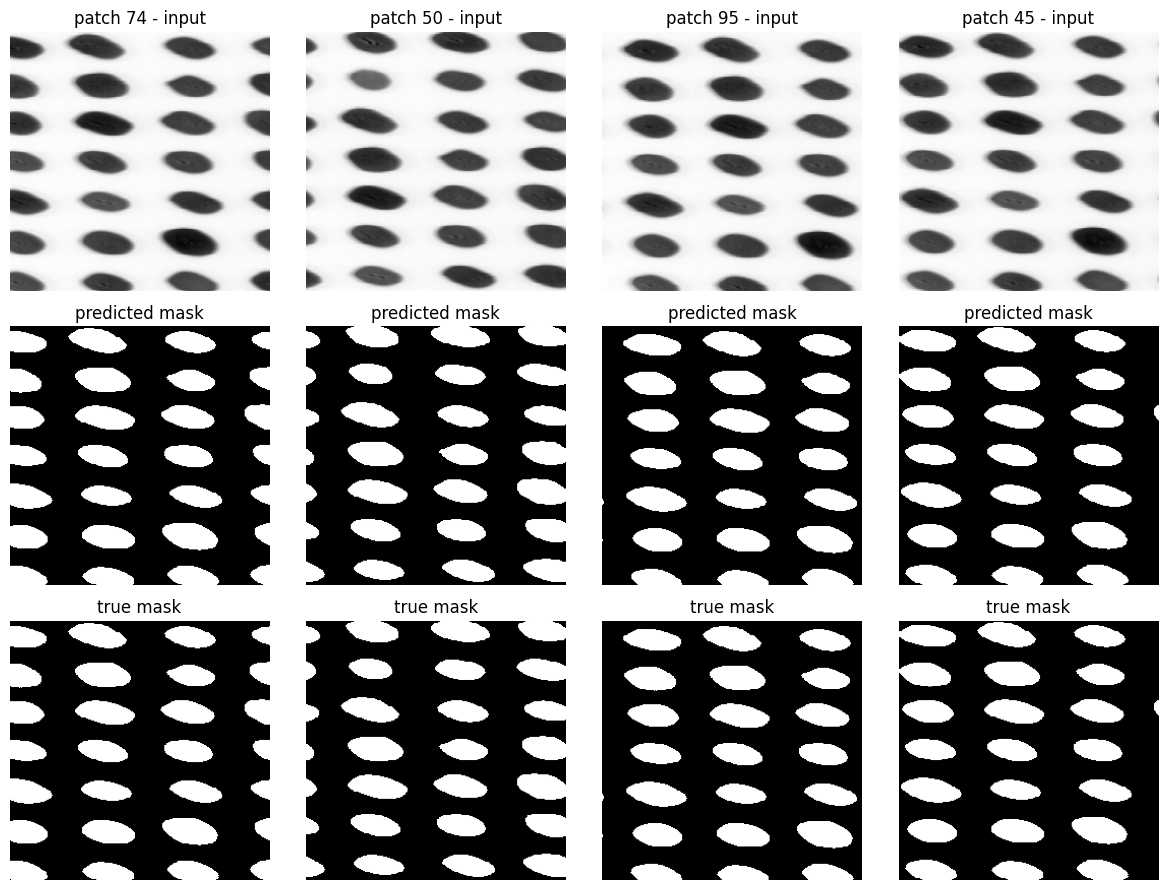

In [13]:
n_show = 4
rng = np.random.default_rng(1)
show_idx = rng.choice(X_test_scaled.shape[0], size=n_show, replace=False)

fig, axes = plt.subplots(3, n_show, figsize=(3 * n_show, 9))
for col, idx in enumerate(show_idx):
    axes[0, col].imshow(X_test_scaled[idx][:, :, 0], cmap='gray')
    axes[0, col].set_title(f'patch {idx} - input')
    axes[1, col].imshow(pred_masks_binary[idx][:, :, 0], cmap='gray')
    axes[1, col].set_title('predicted mask')
    axes[2, col].imshow(true_masks_binary[idx][:, :, 0], cmap='gray')
    axes[2, col].set_title('true mask')
    for row in range(3):
        axes[row, col].axis('off')
plt.tight_layout()
plt.show()

## Train and evaluate the regression model (SSC)

Same architecture and the same `train()` function as segmentation, only the target changes (SSC map instead of segmentation mask), and evaluation is RMSE instead of Jaccard, computed per-grape by averaging predicted pixels inside each grape's mask.


In [14]:
# Free the segmentation models before building the regression ones.
del d_model_seg, gan_model_seg  # g_model_seg is kept above only until you're done inspecting its output
tf.keras.backend.clear_session()
gc.collect()

0

2026-09-07 16:45:39.460301: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion', 8 bytes spill stores, 8 bytes spill loads



>50/1250, d1[0.417] d2[0.418] g[21.960]
>100/1250, d1[0.411] d2[0.412] g[14.468]
>150/1250, d1[0.409] d2[0.409] g[11.193]
>200/1250, d1[0.408] d2[0.409] g[9.347]
>250/1250, d1[0.409] d2[0.409] g[8.124]
>300/1250, d1[0.410] d2[0.410] g[7.267]
>350/1250, d1[0.411] d2[0.411] g[6.627]
>400/1250, d1[0.412] d2[0.412] g[6.120]
>450/1250, d1[0.413] d2[0.413] g[5.707]
>500/1250, d1[0.414] d2[0.414] g[5.376]
>550/1250, d1[0.415] d2[0.415] g[5.108]
>600/1250, d1[0.416] d2[0.416] g[4.864]
>650/1250, d1[0.417] d2[0.417] g[4.655]
>700/1250, d1[0.418] d2[0.418] g[4.465]
>750/1250, d1[0.419] d2[0.419] g[4.298]
>800/1250, d1[0.420] d2[0.420] g[4.147]
>850/1250, d1[0.420] d2[0.421] g[4.008]
>900/1250, d1[0.421] d2[0.421] g[3.886]
>950/1250, d1[0.422] d2[0.422] g[3.770]
>1000/1250, d1[0.422] d2[0.423] g[3.664]
>1050/1250, d1[0.423] d2[0.423] g[3.565]
>1100/1250, d1[0.423] d2[0.424] g[3.476]
>1150/1250, d1[0.424] d2[0.424] g[3.391]
>1200/1250, d1[0.424] d2[0.425] g[3.313]
>1250/1250, d1[0.425] d2[0.425] g

>Saved: data/generative_modelling/regression_run/plot_001250.png and data/generative_modelling/regression_run/model_001250.h5


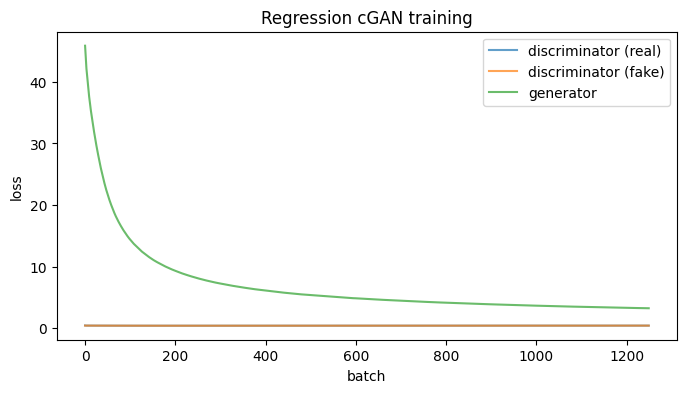

In [15]:
d_model_reg = define_discriminator(image_shape, mask_shape)
g_model_reg = define_generator(image_shape, out_channels=1)
gan_model_reg = define_gan(g_model_reg, d_model_reg, image_shape)

dataset_reg = [X_scaled, ssc_scaled]

history_reg = train(d_model_reg, g_model_reg, gan_model_reg, dataset_reg,
                     n_epochs=10, n_batch=4, out_dir='data/generative_modelling/regression_run')
plot_history(history_reg, title='Regression cGAN training')

Evaluation on the held-out test image, same procedure as segmentation: patch the test scene, run the generator, and compare against ground truth — RMSE this time, restricted to grape pixels (background pixels carry no meaningful SSC reference).


In [16]:
from sklearn.metrics import mean_squared_error

targets_test_full_reg = {'mask': mat_data['mask_test'], 'ssc': mat_data['SSC_test_im']}
X_test_patches_r, Y_test_patches_r = get_paired_patches(X_test_full, targets_test_full_reg,
                                                          patch_size=256, num_patches=100, seed=2)

X_test_scaled_r = (X_test_patches_r - x_min) / (x_max - x_min)
X_test_scaled_r = ((X_test_scaled_r - 0.5) * 2.0).astype('float32')

pred_ssc_scaled = g_model_reg.predict(X_test_scaled_r, verbose=0)
pred_ssc = pred_ssc_scaled * (ssc_max - ssc_min) + ssc_min  # back to real SSC units

true_mask_r = (Y_test_patches_r['mask'] > 0.5)
true_ssc = Y_test_patches_r['ssc']

# RMSE computed only over grape pixels (background pixels carry no meaningful SSC reference)
rmse = np.sqrt(mean_squared_error(true_ssc[true_mask_r], pred_ssc[..., 0][true_mask_r[..., 0]]))
print(f'RMSE on held-out test image (pixel-level, grape pixels only): {rmse:.3f} °Brix')
print('(paper reports RMSE around 1-2 °Brix depending on pre-processing, at the per-grape level)')

RMSE on held-out test image (pixel-level, grape pixels only): 4.047 °Brix
(paper reports RMSE around 1-2 °Brix depending on pre-processing, at the per-grape level)


### A look at the predicted SSC maps

A few test patches: predicted SSC map next to the ground truth, plus a scatter of predicted vs. true SSC over all grape pixels shown — the same predicted-vs-actual idea as the scatter plots in the data fusion notebook, just per-pixel here instead of per-sample.


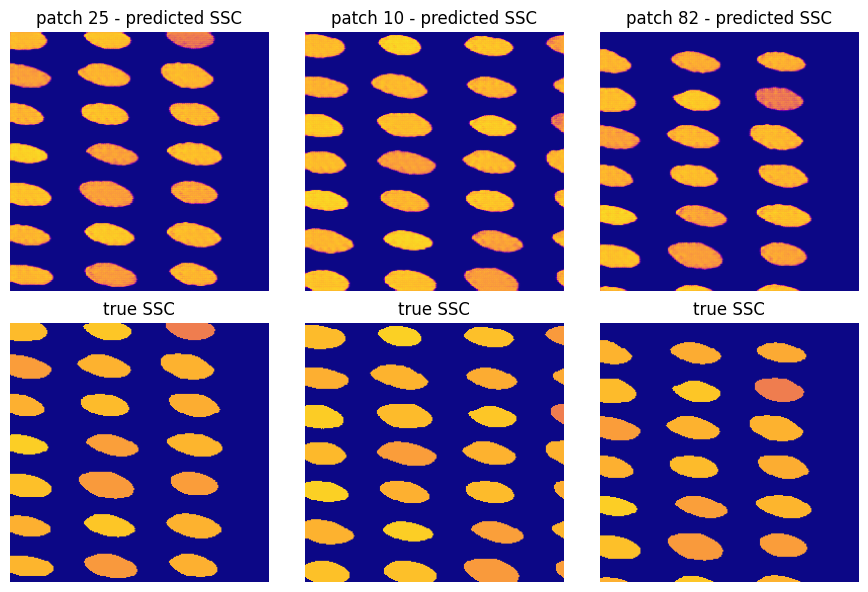

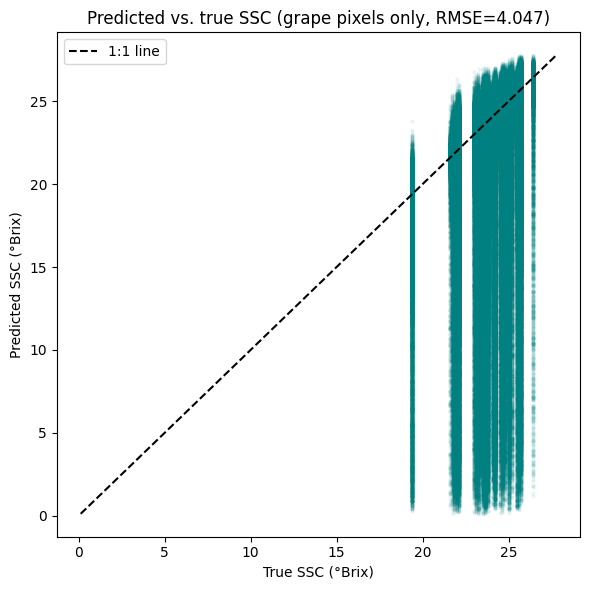

In [17]:
n_show = 3
rng = np.random.default_rng(2)
show_idx = rng.choice(X_test_scaled_r.shape[0], size=n_show, replace=False)

vmin, vmax = ssc_min, ssc_max
fig, axes = plt.subplots(2, n_show, figsize=(3 * n_show, 6))
for col, idx in enumerate(show_idx):
    axes[0, col].imshow(pred_ssc[idx][:, :, 0], cmap='plasma', vmin=vmin, vmax=vmax)
    axes[0, col].set_title(f'patch {idx} - predicted SSC')
    axes[1, col].imshow(true_ssc[idx][:, :, 0], cmap='plasma', vmin=vmin, vmax=vmax)
    axes[1, col].set_title('true SSC')
    for row in range(2):
        axes[row, col].axis('off')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
true_vals = true_ssc[true_mask_r]
pred_vals = pred_ssc[..., 0][true_mask_r[..., 0]]
plt.scatter(true_vals, pred_vals, alpha=0.05, s=5, color='teal')
lims = [min(true_vals.min(), pred_vals.min()), max(true_vals.max(), pred_vals.max())]
plt.plot(lims, lims, 'k--', label='1:1 line')
plt.xlabel('True SSC (°Brix)')
plt.ylabel('Predicted SSC (°Brix)')
plt.title(f'Predicted vs. true SSC (grape pixels only, RMSE={rmse:.3f})')
plt.legend()
plt.tight_layout()
plt.show()

### Per-patch post-processing (mean / median pooling)

The RMSE above is computed pixel by pixel, but in practice a single pooled SSC value per grape is usually what you actually want. We post-process the raw pixel-wise predictions by pooling the predicted pixels inside each patch's grape mask with either the mean or the median, and compare that single pooled value per patch against the (constant-within-mask) ground truth value.


In [18]:
from scipy.ndimage import label

def label_grape_components(mask, min_pixels=10):
    """Connected-component labels for each patch's grape mask.

    Returns a list of (patch_idx, boolean_component_mask) pairs, one per kept
    grape instance, plus how many components were dropped for being smaller
    than `min_pixels` (usually a grape sliced off at the patch edge, or noise).
    """
    mask = np.asarray(mask)
    if mask.ndim == 4:
        mask = mask[..., 0]
    structure = np.ones((3, 3))  # 8-connectivity

    components = []
    n_dropped = 0
    for i in range(mask.shape[0]):
        labeled, n_components = label(mask[i], structure=structure)
        for comp_id in range(1, n_components + 1):
            comp_mask = labeled == comp_id
            if comp_mask.sum() < min_pixels:
                n_dropped += 1
                continue
            components.append((i, comp_mask))
    return components, n_dropped


def pool_components(values, components, how='mean'):
    """Pool `values` over each (patch_idx, component_mask) pair from label_grape_components."""
    values = np.asarray(values)
    if values.ndim == 4:
        values = values[..., 0]
    pool_fn = np.mean if how == 'mean' else np.median
    return np.array([pool_fn(values[i][comp_mask]) for i, comp_mask in components])


min_pixels = 10
grape_components, n_dropped = label_grape_components(true_mask_r, min_pixels=min_pixels)
n_patches_with_grapes = len({i for i, _ in grape_components})
print(f"Found {len(grape_components)} grape instances across {n_patches_with_grapes} patches "
      f"(dropped {n_dropped} components smaller than {min_pixels} px - patch-edge scraps / noise)")

true_grape = pool_components(true_ssc, grape_components, how='mean')  # constant within a grape either way
pred_grape_mean = pool_components(pred_ssc, grape_components, how='mean')
pred_grape_median = pool_components(pred_ssc, grape_components, how='median')

rmse_grape_mean = np.sqrt(mean_squared_error(true_grape, pred_grape_mean))
rmse_grape_median = np.sqrt(mean_squared_error(true_grape, pred_grape_median))

print(f"\nPer-grape RMSE, mean-pooled predictions:   {rmse_grape_mean:.3f} °Brix ({len(true_grape)} grapes)")
print(f"Per-grape RMSE, median-pooled predictions: {rmse_grape_median:.3f} °Brix ({len(true_grape)} grapes)")


Found 2408 grape instances across 100 patches (dropped 17 components smaller than 10 px - patch-edge scraps / noise)

Per-grape RMSE, mean-pooled predictions:   2.187 °Brix (2408 grapes)
Per-grape RMSE, median-pooled predictions: 1.702 °Brix (2408 grapes)


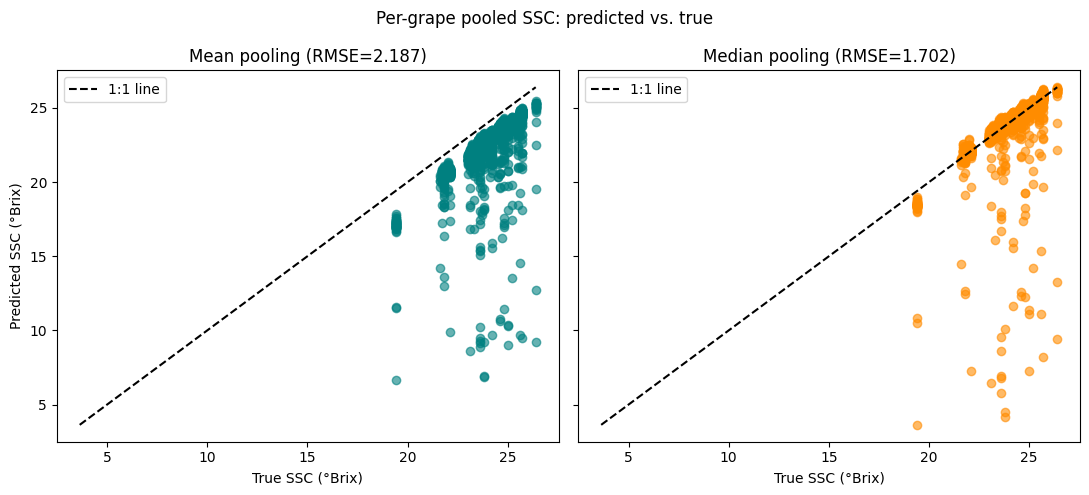

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)

all_vals = np.concatenate([true_grape, pred_grape_mean, pred_grape_median])
lims = [all_vals.min(), all_vals.max()]

axes[0].scatter(true_grape, pred_grape_mean, alpha=0.6, color='teal')
axes[0].plot(lims, lims, 'k--', label='1:1 line')
axes[0].set_xlabel('True SSC (°Brix)')
axes[0].set_ylabel('Predicted SSC (°Brix)')
axes[0].set_title(f'Mean pooling (RMSE={rmse_grape_mean:.3f})')
axes[0].legend()

axes[1].scatter(true_grape, pred_grape_median, alpha=0.6, color='darkorange')
axes[1].plot(lims, lims, 'k--', label='1:1 line')
axes[1].set_xlabel('True SSC (°Brix)')
axes[1].set_title(f'Median pooling (RMSE={rmse_grape_median:.3f})')
axes[1].legend()

plt.suptitle('Per-grape pooled SSC: predicted vs. true')
plt.tight_layout()
plt.show()

Note this still isn't a perfect per-grape metric: because patches are overlapping random crops rather than a stitched full scene, the same grape can appear as separate instances in more than one patch and get counted (and pooled) more than once here.

### Takeaways

- **Segmentation** is the easier of the two tasks here: it only needs a local, translation-invariant rule ("is this pixel grape or background"), so many overlapping crops of a single scene genuinely help - consistent with the high Jaccard scores the paper reports.
- **Regression (SSC)** is more fragile: no matter how many patches you extract, the label diversity is still capped by the number of grapes in the training scene, so the model will likely be overfitting to that small set of reference values.
- **On the memory**: keeping two full-size pix2pix model sets (segmentation + regression) alive in memory at once is heavy. Use `clear_session()` + `gc.collect()` to not run out of memory.